<a href="https://colab.research.google.com/github/Danielnodn/academic-ml-projects/blob/main/feature_engeneering/california_housing/cali_housing_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Food Inspection Risk Analysis
Author: Daniel Ramirez

Original version:
- Data ingestion from AWS S3
- Credentials handled via YAML
- Cloud-based storage

Current version:
- Local CSV loading for reproducibility
- AWS logic preserved as commented reference
"""

#!pip install yaml
#!pip install boto3
#!pip install pickle
#!pip install sodapy

'\nFood Inspection Risk Analysis\nAuthor: Daniel Ramirez\n\nOriginal version:\n- Data ingestion from AWS S3\n- Credentials handled via YAML\n- Cloud-based storage\n\nCurrent version:\n- Local CSV loading for reproducibility\n- AWS logic preserved as commented reference\n'

In [1]:
!pip install -r sample_data/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
# !pip install pandas numpy boto3 scikit-learn pyyaml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# AWS S3 integration (original reference)
# import boto3
# import yaml
# from io import StringIO

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
"""
# import boto3
# import yaml
# from io import StringIO

# def load_data_s3(bucket, key, credentials_path):
#     with open(credentials_path, 'r') as file:
#         creds = yaml.safe_load(file)

#     s3 = boto3.client(
#         's3',
#         aws_access_key_id=creds['aws_access_key_id'],
#         aws_secret_access_key=creds['aws_secret_access_key']
#     )

#     obj = s3.get_object(Bucket=bucket, Key=key)
#     data = obj['Body'].read().decode('utf-8')
#     return pd.read_csv(StringIO(data))
"""

"\n# import boto3\n# import yaml\n# from io import StringIO\n\n# def load_data_s3(bucket, key, credentials_path):\n#     with open(credentials_path, 'r') as file:\n#         creds = yaml.safe_load(file)\n\n#     s3 = boto3.client(\n#         's3',\n#         aws_access_key_id=creds['aws_access_key_id'],\n#         aws_secret_access_key=creds['aws_secret_access_key']\n#     )\n\n#     obj = s3.get_object(Bucket=bucket, Key=key)\n#     data = obj['Body'].read().decode('utf-8')\n#     return pd.read_csv(StringIO(data))\n"

In [ ]:
def load_data():
    train = pd.read_csv("../data/california_housing_train.csv")
    test = pd.read_csv("../data/california_housing_test.csv")
    return train, test

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

In [ ]:
# FEATURE ENGINEERING

def feature_engineering(df):

    df = df.copy()

    # Create rooms per household
    df["rooms_per_household"] = df["total_rooms"] / df["households"]

    # Bedrooms per room
    df["bedrooms_ratio"] = df["total_bedrooms"] / df["total_rooms"]

    # Population per household
    df["population_per_household"] = df["population"] / df["households"]

    return df


In [ ]:
# MODEL TRAINING

def train_model(train, test):

    train = feature_engineering(train)
    test = feature_engineering(test)

    X_train = train.drop(columns=["median_house_value"])
    y_train = train["median_house_value"]

    X_test = test.drop(columns=["median_house_value"])
    y_test = test["median_house_value"]

    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print("Model Performance")
    print("------------------")
    print("RMSE:", rmse)
    print("R²:", r2)

    return model

In [ ]:
# MAIN

def load_data():
    train = pd.read_csv("/content/sample_data/california_housing_train.csv")
    test = pd.read_csv("/content/sample_data/california_housing_test.csv")
    return train, test

if __name__ == "__main__":

    train, test = load_data()
    model = train_model(train, test)

Model Performance
------------------
RMSE: 50980.34551641028
R²: 0.7968232800296317


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return rmse, r2

In [ ]:
train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

X_train = train_fe.drop(columns=["median_house_value"])
y_train = train_fe["median_house_value"]

X_test = test_fe.drop(columns=["median_house_value"])
y_test = test_fe["median_house_value"]


In [ ]:
#Comparación:

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    rmse, r2 = evaluate_model(model, X_train, y_train, X_test, y_test)
    print(f"{name}")
    print("RMSE:", rmse)
    print("R²:", r2)
    print("-"*30)

Linear Regression
RMSE: 68888.7172857506
R²: 0.6290079593475704
------------------------------
Random Forest
RMSE: 50980.34551641028
R²: 0.7968232800296317
------------------------------
Gradient Boosting
RMSE: 53672.97188739647
R²: 0.774794142703342
------------------------------


#Linear Regression

Is a baseline regression algorithm that models the relationship between features and target using a linear equation.

It finds the best-fitting straight line by minimizing the squared error between predicted and actual values.

It works well when:

* Relationships are mostly linear
* When data has low complexity

Why performance may be lower here:

Housing prices are influenced by complex, non-linear relationships that a
simple linear model cannot fully capture.



#Random Forest Regressor

In this project Random Forest will achieved the best R² score, indicating strong predictive power for complex housing data patterns.

It`s an ensemble learning method based on multiple decision trees.

It builds many decision trees on random subsets of the data

Each tree makes a prediction

Final prediction = average of all trees

Why it performs well:

* Captures non-linear relationships

* Reduces overfitting via randomness

* Handles feature interactions automatically


#Gradient Boosting Regressor

It performed slightly below Random Forest but still significantly better than Linear Regression.

It is an advanced ensemble model that builds trees sequentially.

Each new tree focuses on correcting the errors of the previous one

Improves performance step by step

Minimizes residual errors

Why it is powerful:

* Very strong predictive performance

* Learns complex patterns

* Often outperforms simpler ensembles

How to Explain the Metrics



#R² Score

Represents how much variance in the target variable is explained by the model.

Closer to 1 → better

0.79 means 79% of variance explained

RMSE (Root Mean Squared Error)

Measures average prediction error in original units (USD here).

* Lower = better

Easier to interpret in business terms

Example:

An RMSE of 50,980 means predictions are off by approximately $50,980 on average

In [ ]:
from sklearn.model_selection import cross_val_score

def cross_validate_model(model, X, y):
    scores = cross_val_score(model, X, y,
                             scoring="r2",
                             cv=5)
    print("Cross-validated R²:", scores.mean())

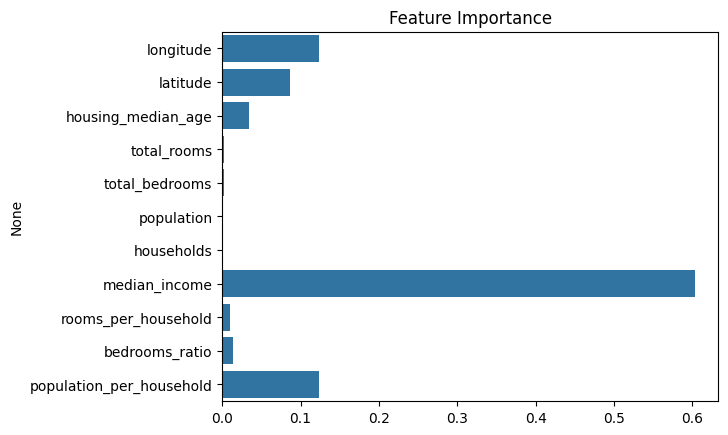

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = X_train.columns

plt.figure()
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [ ]:
results = []

for name, model in models.items():
    rmse, r2 = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print(results_df.sort_values("R2", ascending=False))

               Model          RMSE        R2
1      Random Forest  50980.345516  0.796823
2  Gradient Boosting  53672.971887  0.774794
0  Linear Regression  68888.717286  0.629008


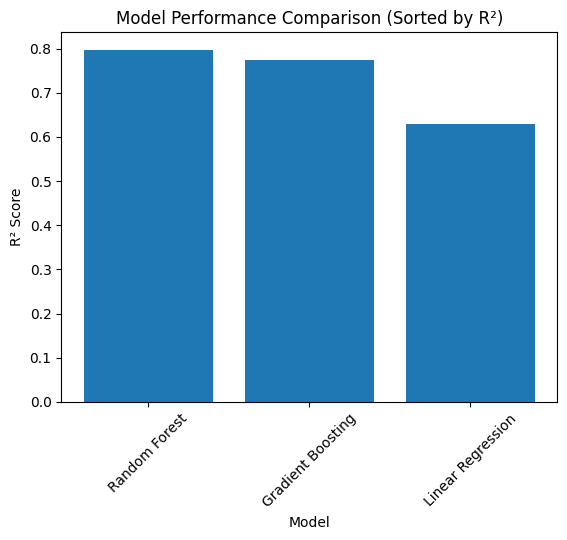

In [ ]:
results_sorted = results_df.sort_values("R2", ascending=False)

plt.figure()
plt.bar(results_sorted["Model"], results_sorted["R2"])

plt.title("Model Performance Comparison (Sorted by R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib

best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.joblib")

['best_model.joblib']

#Conslusions:

 Random Forest and Gradient Boosting substantially outperformed Linear Regression, reducing prediction error by nearly $18,000 on average compared to the linear baseline.

This suggests that:
* Housing prices are driven by complex, non-linear interactions between demographic and geographic features.
* Tree-based ensemble models are better suited to capture these relationships, making them more effective for real estate price prediction tasks.

*Among all evaluated models, Random Forest delivered the best balance of explanatory power and prediction accuracy, making it the strongest candidate for deployment.*

#Final Insights

The results show a clear performance gap between linear and ensemble-based methods.

Linear Regression achieved an R² of 0.63, indicating that it explains about 63% of the variance in housing prices. However, its relatively high RMSE (~$68,888) suggests that the model struggles to capture complex relationships in the data.

Random Forest significantly improved performance, achieving an R² of 0.797 and reducing prediction error to approximately $50,980. This indicates that nearly 80% of the variance in housing prices is explained by the model.

Gradient Boosting also performed strongly (R² = 0.775), but slightly below Random Forest in this case.